# *Understanding Game Trends: The Proportion of Action Games and Their Review Scores*




## 1. Introduction

*Understanding Game Trends: The Proportion of Action Games and Their Review Scores*

This project uses the Video Games Dataset (2004–2010), which contains information about over 1,700 video games, including their genre, sales, ratings, and other characteristics. The data was originally collected and curated by Dr. Joe Cox and includes details such as review scores, year released, publisher, and game features (e.g., whether a game supports multiple players or is an Action title).

Confidence Interval Task:

What proportion of games in our dataset are classified as Action games?

What is a 95% confidence interval for the proportion of Action games in the broader population of video games?

Hypothesis Testing Task:

What is the average Review Score for games in the dataset?

Is there statistical evidence that the mean Review Score differs from 75 in the larger population?

These research questions help understand trends in the video game industry during a crucial growth period. Estimating the proportion of Action games provides insight into how dominant that genre was in the market, which could be valuable for developers or marketers deciding which genres to focus on. Analyzing review score helps us gauge overall game quality and whether players tended to rate these games highly. 

Hypothesis Statements

Null Hypothesis (H₀):
The true mean review score for all video games released between 2004 and 2010 is μ = 75.

Alternative Hypothesis (Hₐ):
The true mean review score for all video games released between 2004 and 2010 is μ ≠ 75.

In [2]:
import pandas as pd
df = pd.read_csv('video_games.csv', encoding='unicode-escape')
print('Rows, columns:', df.shape)
print('\nSome columns (first 20):', list(df.columns)[:20])
df.head(100)

Rows, columns: (1770, 166)

Some columns (first 20): ['Console', 'Title', 'US Sales (millions)', 'Block4', 'Block2', 'Block1', 'Block0.5', 'YearReleased', '2004', '2005', '2006', '2007', '2008', '2009', '2010', 'YearReleasedSq', 'Publisher', 'Genre', 'Sequel', 'Re-release']


,Console,Title,US Sales (millions),Block4,Block2,Block1,Block0.5,YearReleased,2004,2005,...,Tricks,Volleyball,Wakeboarding,Wrestling,FirstPerson,Platform,Isometric,SideScrolling,TopDown,ThirdPerson
0,Nintendo DS,Super Mario 64 DS,4.69,1,1,1,1,2004,1,0,...,0,0,0,0,0,1,0,0,0,1
1,Sony PSP,Lumines: Puzzle Fusion,0.56,0,0,0,1,2004,1,0,...,0,0,0,0,0,0,0,0,0,0
2,Nintendo DS,WarioWare Touched!,0.54,0,0,0,1,2004,1,0,...,0,0,0,0,0,1,1,1,1,1
3,Sony PSP,Hot Shots Golf: Open Tee,0.49,0,0,0,0,2004,1,0,...,0,0,0,0,0,0,0,0,0,1
4,Nintendo DS,Spider-Man 2,0.45,0,0,0,0,2004,1,0,...,0,0,0,0,0,1,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,Sony PSP,MVP Baseball,0.21,0,0,0,0,2005,0,1,...,0,0,0,0,0,0,0,0,0,0
96,Sony PSP,NBA,0.21,0,0,0,0,2005,0,1,...,0,0,0,0,0,0,0,0,0,1
97,Sony PSP,Tiger Woods PGA Tour,0.21,0,0,0,0,2005,0,1,...,0,0,0,0,0,0,0,0,0,1
98,Sony PSP,World Series of Poker,0.21,0,0,0,0,2005,0,1,...,0,0,0,0,0,0,0,0,1,1


In [6]:
df["Genre"]


0                                 Action
1                               Strategy
2       Action, Racing / Driving, Sports
3                                 Sports
4                                 Action
                      ...               
1765                    Racing / Driving
1766                              Action
1767                 Adventure, Strategy
1768        Role-Playing (RPG), Strategy
1769                              Action
Name: Genre, Length: 1770, dtype: object

In [5]:
df["Genre"].value_counts

<bound method IndexOpsMixin.value_counts of 0                                 Action
1                               Strategy
2       Action, Racing / Driving, Sports
3                                 Sports
4                                 Action
                      ...               
1765                    Racing / Driving
1766                              Action
1767                 Adventure, Strategy
1768        Role-Playing (RPG), Strategy
1769                              Action
Name: Genre, Length: 1770, dtype: object>

In [10]:
df["Genre"].unique

<bound method Series.unique of 0                                 Action
1                               Strategy
2       Action, Racing / Driving, Sports
3                                 Sports
4                                 Action
                      ...               
1765                    Racing / Driving
1766                              Action
1767                 Adventure, Strategy
1768        Role-Playing (RPG), Strategy
1769                              Action
Name: Genre, Length: 1770, dtype: object>

## 2. Confidence Interval Analytical Tasks

 **Logical variable**: `is_action` — created from the `Action` column (1 if Action==1 else 0).
- **Quantitative variable**: `Review Score` — numerical score (used for hypothesis test).

Research question (descriptive): What proportion of games in our sample are Action games?

Research question (inferential): What is a 95% confidence interval for the proportion of Action games in the underlying population?

In [9]:

df['is_action'] = df['Action'].apply(lambda x: 1 if x==1 else 0)
n = df.shape[0]
p_hat = df['is_action'].mean()
print('Sample size n =', n)
print('Sample proportion p̂ =', round(p_hat,4))


import numpy as np

samp_dist = []
for i in range(5000):
    samp = df.sample(n=n, replace=True)
    samp_dist.append(samp['is_action'].mean())
samp_dist = np.array(samp_dist)
ci_lower, ci_upper = np.percentile(samp_dist, [2.5, 97.5])
print('\n95% bootstrap CI for proportion:', round(ci_lower,4), 'to', round(ci_upper,4))



Sample size n = 1770
Sample proportion p̂ = 0.6079

95% bootstrap CI for proportion: 0.5853 to 0.6305


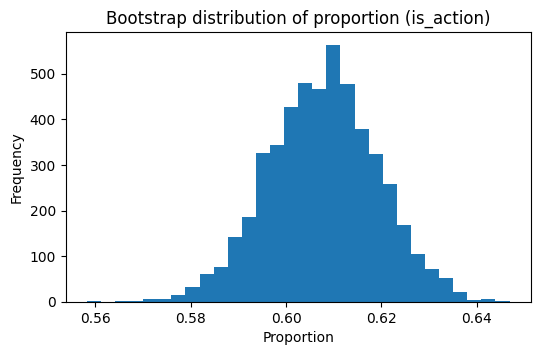

In [ ]:

import matplotlib.pyplot as plt
plt.figure(figsize=(6,3.5))
plt.hist(boot_props, bins=30)
plt.title('Bootstrap distribution of proportion (is_action)')
plt.xlabel('Proportion')
plt.ylabel('Frequency')
plt.show()

We are 95% confident that the true proportion of all video games (released between 2004 and 2010) that are Action games lies between 0.585 and 0.629.

## 3. Hypothesis Testing Analytical Tasks

## Hypothesis test task (Review Score)

Research question (descriptive): What is the sample mean of review scores?

Research question (inferential): Does the data provide evidence that the mean review score differs from 75? (H₀: μ = 75 vs H₁: μ ≠ 75).

In [ ]:
df['Review Score'] = pd.to_numeric(df['Review Score'], errors='coerce')
reviews = df['Review Score'].dropna()
n_rev = reviews.shape[0]
mean_rev = reviews.mean()
median_rev = reviews.median()
std_rev = reviews.std(ddof=1)
print('n (review scores) =', n_rev)
print('Mean review score =', round(mean_rev,2))
print('Median review score =', round(median_rev,2))
print('Std. dev. =', round(std_rev,2))

n (review scores) = 1770
Mean review score = 68.43
Median review score = 70.0
Std. dev. = 13.89


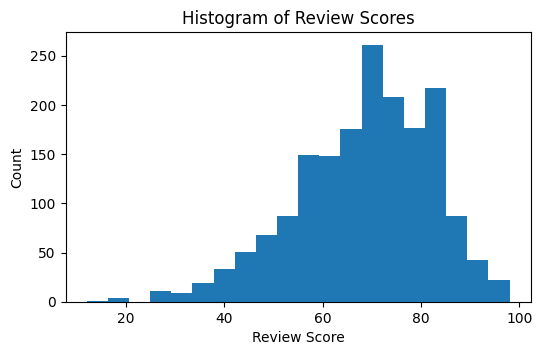

In [ ]:
plt.figure(figsize=(6,3.5))
plt.hist(reviews, bins=20)
plt.title('Histogram of Review Scores')
plt.xlabel('Review Score')
plt.ylabel('Count')
plt.show()

In [ ]:
null_mu = 75

centered = reviews - mean_rev
boot_means_null = []
for i in range(5000):
    resamp = centered.sample(n=n_rev, replace=True).values + null_mu
    boot_means_null.append(resamp.mean())
boot_means_null = np.array(boot_means_null)

In [ ]:
extreme = np.sum(np.abs(boot_means_null - null_mu) >= abs(mean_rev - null_mu))
p_value = extreme / 5000
print('\nObserved mean =', round(mean_rev,3))
print('Null hypothesis mean =', null_mu)
print('Bootstrap p-value (two-sided) =', p_value)


Observed mean = 68.429
Null hypothesis mean = 75
Bootstrap p-value (two-sided) = 0.0


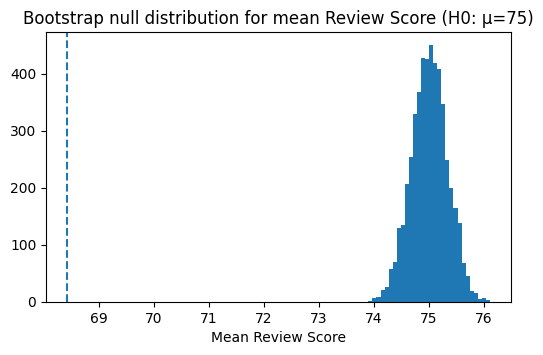

In [ ]:
plt.figure(figsize=(6,3.5))
plt.hist(boot_means_null, bins=30)
plt.axvline(mean_rev, linestyle='--')
plt.title('Bootstrap null distribution for mean Review Score (H0: μ=75)')
plt.xlabel('Mean Review Score')
plt.show()

The probability of obtaining a sample mean review score as far from 75 as the one observed (68.43)—or farther—if the true mean were really 75 is essentially 0. This provides strong evidence against the null hypothesis.

Therefore, we reject H₀ and conclude that the true mean review score for video games in this period is significantly different from 75 (and likely lower, since the sample mean < 75).

## 4. Conclusion

**Confidence interval result:**

- Sample proportion of Action games: 0.6079 (n = 1770) 
- 95% CI for population proportion: (0.5853, 0.6294)  

**Hypothesis test result :**

- Sample mean Review Score: 68.429 (n = 1770) 
- Null hypothesis tested: μ = 75
- Two-sided bootstrap p-value = 0.0000

**Interpretation:**

- The 95% CI gives a plausible range for the proportion of Action games in the population.  
- The p-value above indicates whether we have evidence against H₀: μ = 75.  A small p-value (≤ 0.05) would tell us that the mean review score differs from 75.

**Limitations & future work:**

- The dataset covers games released from 2004–2010 and may not represent modern releases.  
- Bootstrapping is simple and appropriate here, but more advanced modeling could adjust for platform differences or year effects.

**Future work and questions:**

- What our the review scores for other genres?
- What genre has the highest review score? 
- Do review scores effect sales across years between genres?